# Librerías

In [1]:
import pandas as pd
import numpy as np
import wfdb
import ast
import matplotlib.pyplot as plt
import os
from collections import Counter
from scipy.fft import fft, fftfreq
import scipy.signal as signal
from scipy.signal import welch, butter, filtfilt
from scipy.integrate import trapezoid
import seaborn as sns
import pandas as pd
import ast
from pathlib import Path
from matplotlib.patches import Patch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Carga de Datos

Carga -- Resamplear a 100 Hz -- Guardar en dict. individual -- Verificar -- Unir todo a un dict. total -- Cargarlo a un archivo HDF5 para no sobrecargar la RAM

**Estandarización:** El objetivo de esta fase es que todas las bases de datos crudas terminen en el mismo formato.

## PTB-XL

In [3]:
import os
import ast
import pandas as pd
from pathlib import Path
import wfdb  # Librería para leer archivos .dat y .hea de PhysioNet
import h5py  # Para guardar en disco

# 1. Tu código original de carga
PATH_DATA = Path('../data/raw/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3') 

if not PATH_DATA.exists():
    print(f"Error: No se encontró la carpeta de datos en {PATH_DATA.resolve()}")
else:
    df_meta = pd.read_csv(os.path.join(PATH_DATA, 'ptbxl_database.csv'), index_col='ecg_id')
    df_meta['scp_codes'] = df_meta['scp_codes'].apply(lambda x: ast.literal_eval(x))
    print("¡Dataset de metadatos cargado exitosamente!")

# 2. Lógica para procesar las señales de 100 Hz y guardarlas
print("Iniciando extracción y guardado de señales a 100 Hz...")

# Creamos nuestro contenedor HDF5 final
with h5py.File('ptbxl_procesado_100hz.h5', 'w') as hf:
    
    # Iteramos sobre cada fila del DataFrame usando el ecg_id
    for ecg_id, fila in df_meta.iterrows():
        
        # 'filename_lr' tiene rutas como "records100/00000/00001_lr"
        ruta_relativa_100hz = fila['filename_lr'] 
        ruta_completa = os.path.join(PATH_DATA, ruta_relativa_100hz)
        
        try:
            # wfdb.rdrecord lee automáticamente los archivos .dat y .hea
            registro = wfdb.rdrecord(ruta_completa)
            
            # Extraemos la matriz de la señal (numpy array)
            # Para PTB-XL, esto suele ser un array de forma (1000, 12) -> 10 seg * 100Hz, 12 derivaciones
            matriz_senal = registro.p_signal 
            
            # Guardamos la matriz en el HDF5 usando el ecg_id como llave
            hf.create_dataset(str(ecg_id), data=matriz_senal)
            
        except Exception as e:
            print(f"Error procesando el registro {ecg_id}: {e}")

print("¡Proceso completado! Todas las señales de 100 Hz están en el archivo HDF5.")

¡Dataset de metadatos cargado exitosamente!
Iniciando extracción y guardado de señales a 100 Hz...
¡Proceso completado! Todas las señales de 100 Hz están en el archivo HDF5.


¡Archivo cargado! Contiene 21799 registros en total.
Forma de la señal extraída: (1000, 12)


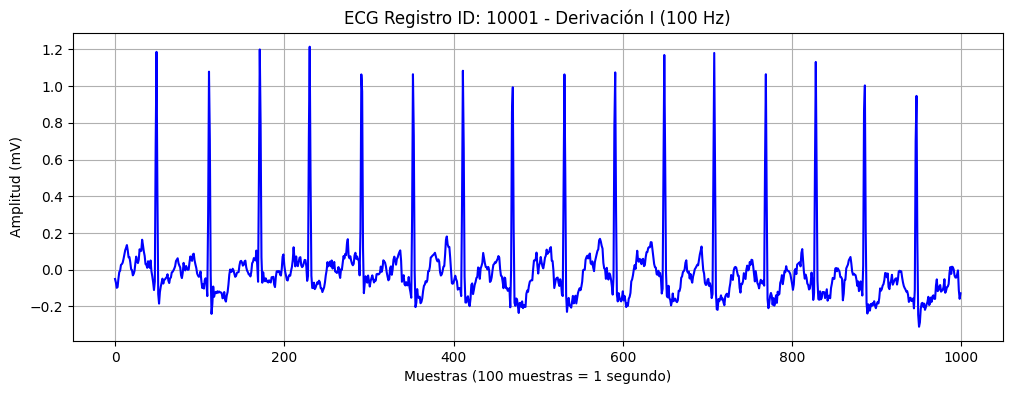

In [7]:
import h5py
import matplotlib.pyplot as plt

# 1. Abrimos el archivo en modo lectura ('r')
with h5py.File('ptbxl_procesado_100hz.h5', 'r') as hf:
    
    # Obtenemos una lista de todos los IDs guardados
    todos_los_ids = list(hf.keys())
    print(f"¡Archivo cargado! Contiene {len(todos_los_ids)} registros en total.")
    
    # Seleccionamos el primer registro de la lista
    primer_id = todos_los_ids[5]  # Cambia el índice según el registro que quieras visualizar
    
    # Extraemos la matriz de la señal a la memoria RAM
    matriz_senal = hf[primer_id][:]

# 2. Imprimimos la forma de la matriz (debería ser 1000 muestras x 12 derivaciones)
print(f"Forma de la señal extraída: {matriz_senal.shape}")

# 3. Graficamos la primera derivación (columna 0)
plt.figure(figsize=(12, 4))
plt.plot(matriz_senal[:, 0], color='blue') 
plt.title(f"ECG Registro ID: {primer_id} - Derivación I (100 Hz)")
plt.xlabel("Muestras (100 muestras = 1 segundo)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)
plt.show()

## CPSC 2018

In [5]:
import os
from pathlib import Path
import wfdb
import h5py
import numpy as np
from scipy.signal import resample
from tqdm import tqdm

# 1. Definimos la ruta a la carpeta Training_WFDB
PATH_CPSC = Path('../data/raw/Training_WFDB')

if not PATH_CPSC.exists():
    print(f"Error: No se encontró la carpeta en {PATH_CPSC.resolve()}")
else:
    # wfdb usa dos archivos por registro (.hea y .mat/.dat). 
    # Buscamos todos los .hea y nos quedamos con el nombre sin la extensión.
    archivos_hea = list(PATH_CPSC.glob('*.hea'))
    nombres_registros = [str(archivo.with_suffix('')) for archivo in archivos_hea]
    
    print(f"¡Carpeta encontrada! Se detectaron {len(nombres_registros)} registros para procesar.")
    
    # Frecuencia objetivo para unificar
    fs_objetivo = 100
    
    # 2. Creamos el contenedor HDF5 para esta base de datos
    with h5py.File('cpsc2018_procesado_100hz.h5', 'w') as hf:
        
        # 3. Iteramos con barra de progreso
        for ruta_registro in tqdm(nombres_registros, desc="Resampleando CPSC 2018"):
            
            # Extraemos solo el ID del archivo (ej: 'A0001')
            id_registro = os.path.basename(ruta_registro)
            
            try:
                # Leemos el registro original
                registro = wfdb.rdrecord(ruta_registro)
                senal_original = registro.p_signal
                fs_original = registro.fs
                
                # Verificamos que haya datos
                if senal_original is None:
                    continue
                
                # 4. Resampleo (si la frecuencia original es distinta a la objetivo)
                if fs_original != fs_objetivo:
                    # Calculamos el nuevo número de muestras
                    # axis=0 asegura que resamplea a lo largo del tiempo, no de las 12 derivaciones
                    muestras_nuevas = int(senal_original.shape[0] * (fs_objetivo / fs_original))
                    senal_procesada = resample(senal_original, muestras_nuevas, axis=0)
                else:
                    # Si por algún motivo ya está a 100Hz, la dejamos igual
                    senal_procesada = senal_original
                    
                # 5. Guardamos en el HDF5
                hf.create_dataset(id_registro, data=senal_procesada)
                
            except Exception as e:
                print(f"\nError procesando el registro {id_registro}: {e}")

    print("\n¡Proceso de CPSC 2018 completado! Señales resampleadas y guardadas a 100 Hz.")

¡Carpeta encontrada! Se detectaron 6877 registros para procesar.


Resampleando CPSC 2018: 100%|██████████| 6877/6877 [00:51<00:00, 133.33it/s]


¡Proceso de CPSC 2018 completado! Señales resampleadas y guardadas a 100 Hz.


¡Archivo cargado! Contiene 6877 registros en total.
Forma de la señal extraída: (1400, 12)


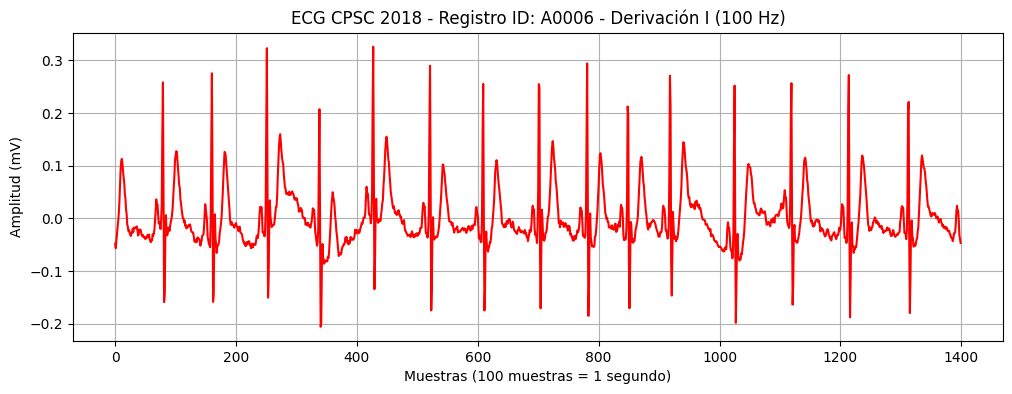

In [8]:
import h5py
import matplotlib.pyplot as plt

# 1. Abrimos el archivo contenedor de CPSC 2018
with h5py.File('cpsc2018_procesado_100hz.h5', 'r') as hf:
    
    # Obtenemos todos los IDs (En CPSC suelen llamarse 'A0001', 'A0002', etc.)
    todos_los_ids_cpsc = list(hf.keys())
    print(f"¡Archivo cargado! Contiene {len(todos_los_ids_cpsc)} registros en total.")
    
    # Seleccionamos el primer registro
    primer_id_cpsc = todos_los_ids_cpsc[5]  # Cambia el índice según el registro que quieras visualizar
    
    # Extraemos la señal a la memoria
    matriz_senal_cpsc = hf[primer_id_cpsc][:]

# 2. Imprimimos la forma de la matriz
print(f"Forma de la señal extraída: {matriz_senal_cpsc.shape}")

# 3. Graficamos la primera derivación (columna 0)
plt.figure(figsize=(12, 4))
plt.plot(matriz_senal_cpsc[:, 0], color='red') # Usamos rojo para distinguirlo de PTB-XL
plt.title(f"ECG CPSC 2018 - Registro ID: {primer_id_cpsc} - Derivación I (100 Hz)")
plt.xlabel("Muestras (100 muestras = 1 segundo)")
plt.ylabel("Amplitud (mV)")
plt.grid(True)
plt.show()

A diferencia de PTB-XL estos registros son de duración variable por eso podemos ver 1400 o 1500 muestras. Esto debe ser considerado a la hora de diseñar la arquitectura de la red neuronal.

Esta base de datos identifica LBBB (Bloqueo Izquierdo) y RBBB (Bloqueo Derecho)

# 

**Unificación de Etiquetas (Metadatos):** Una vez que están todos los .h5 listos, armamos un "Super DataFrame" donde unificamos los diagnósticos de todas las bases de datos en un solo formato estándar.

**Preprocesamiento y Modelado:** Limpieza de ruido, división en Train/Test y entrenamiento del modelo.